# Q9 Revenue Sources: Black Hills vs Benchmark Regions

This notebook answers:

> **For the limited number of organizations filing Form 990, Form 990-EZ, or Form 990-PF, is there a difference in revenue sources between Black Hills and benchmark regions?**

The primary statistical answer now uses **organization-level raw revenue-source dollar values**, not revenue-source shares. This change addresses the compositional-share concern: revenue-source shares are parts of a whole, so separate share values are not independent in the same way raw source-dollar variables are.

The notebook still includes stacked share charts, but those charts are descriptive revenue-mix visuals only. They are not the values used in the primary statistical tests.


## 1. Setup

The notebook imports the same analysis module used by the production `.py` script. That keeps the notebook and scripted outputs aligned: the same raw fields, exclusions, variable definitions, tests, and chart helpers are used in both places.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, display

# Find the repository root whether the notebook is executed from the repo root
# or from the notebook folder.
START = Path.cwd().resolve()
for candidate in [START, *START.parents]:
    if (candidate / 'python' / 'analysis' / 'revenue_sources_black_hills' / 'revenue_sources_black_hills.py').exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError('Could not find repository root.')

ANALYSIS_DIR = REPO_ROOT / 'python' / 'analysis' / 'revenue_sources_black_hills'
RESULTS_DIR = ANALYSIS_DIR / 'results'
TABLES_DIR = RESULTS_DIR / 'tables'
ASSETS_DIR = RESULTS_DIR / 'client_notebook_assets'

if str(REPO_ROOT / 'python') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'python'))
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))

import revenue_sources_black_hills as r

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)


## 2. Load and prepare the analysis data

The primary frame uses the GivingTuesday Form 990-family analysis file for tax year 2022. The frame excludes hospitals, universities, and political organizations so the comparison is closer to the client-peer universe.

The grain is **organization-year**: one filing by one organization in one tax year.


In [2]:
YEARS = [2022]
raw_gt = r.load_givingtuesday_analysis(r.DEFAULT_DATA_ROOT, YEARS)
raw_benchmark = r.load_givingtuesday_raw_benchmark(r.DEFAULT_DATA_ROOT, YEARS)
raw_field_validation = r.build_raw_field_validation_table(raw_benchmark, raw_gt)
analysis = r.prepare_givingtuesday_analysis(raw_gt, exclude_outliers=True)

coverage = pd.DataFrame({
    'metric': [
        'organization-year rows',
        'unique EINs',
        'tax years',
        'regions',
    ],
    'value': [
        f'{len(analysis):,}',
        f'{analysis.ein.nunique():,}',
        ', '.join(sorted(analysis.tax_year.astype(str).unique())),
        ', '.join(r.REGION_ORDER),
    ],
})
coverage


[revenue-sources] Loading primary GivingTuesday analysis file: C:\Users\eilke\Desktop\Github Repo\swb_project_321\data\321_Black_Hills_Area_Community_Foundation_2025_08\01_data\staging\filing\givingtuesday_990_basic_allforms_analysis_variables.parquet


[revenue-sources] Loaded GivingTuesday rows=4,380, columns=67


[revenue-sources] Rows after requested-year filter ['2022']: 1,872


[revenue-sources] Checking raw GivingTuesday benchmark file for validation: C:\Users\eilke\Desktop\Github Repo\swb_project_321\data\321_Black_Hills_Area_Community_Foundation_2025_08\01_data\staging\filing\givingtuesday_990_basic_allforms_benchmark.parquet


[revenue-sources] Loaded raw benchmark validation rows=1,872, columns=295


[revenue-sources] Deriving primary analysis variables from GivingTuesday fields.


[revenue-sources] Applying requested outlier exclusion. Rows before=1,872, after=1,847


[revenue-sources] Rows after valid geography/form/year and positive revenue filter: 1,799 of 1,847


[revenue-sources] Finished deriving revenue amounts, revenue shares, source flags, and revenue-size strata.


,metric,value
0,organization-year rows,"1,799"
1,unique EINs,"1,797"
2,tax years,2022
3,regions,"Black Hills, Billings, Flagstaff, Sioux Falls,..."


## 3. Requested variables and raw-field lineage

The primary Q9 variables are organization-level raw dollar amounts. The analysis uses the most detailed revenue-source categories that are useful to the client and directly available in the current Form 990-family data.

| Client-facing concept | Analysis variable | Notes |
| --- | --- | --- |
| Total revenue | `total_revenue` | Form 990 `TOTREVCURYEA`; 990-EZ `TOTALRREVENU`; 990-PF `ANREEXTOREEX`. |
| Earned program revenue | `program_service_revenue` | Form 990 `TOTPROSERREV`; 990-EZ `PROGSERVREVE`; 990-PF stays missing because this source does not provide a comparable PF program-service revenue concept. Blank supported 990/990-EZ lines are treated as zero. |
| Total contributions | `total_contributions` | Form 990 `TOTACASHCONT`; 990-EZ `CONGIFGRAETC`; 990-PF `STREACGRTOIN`. Blank supported lines are treated as zero. |
| Government grants | `government_grants_received` | Form 990 Line 1e `GOVERNGRANTS`; 990-EZ/PF rows are excluded for this variable because those forms do not expose the same subcomponent. |
| Federated campaign contributions | `federated_campaigns` | Form 990 Line 1a `FEDERACAMPAI`; 990-EZ/PF rows are excluded for this variable because source detail is unavailable. |
| Related organization contributions | `related_org_contributions` | Form 990 Line 1d `RELATEORGANI`; 990-EZ/PF rows are excluded for this variable because source detail is unavailable. |
| Membership dues | `membership_dues` | Form 990 Line 1b `MEMBERDUESUE`; individual-adjacent, not pure individual giving. 990-EZ/PF rows are excluded for this variable. |
| Fundraising event contributions | `fundraising_events_contributions` | Form 990 Line 1c `FUNDRAEVENTS`; individual-adjacent, not pure individual giving. 990-EZ/PF rows are excluded for this variable. |
| Mixed / unclassified contributions | `mixed_unclassified_contributions` | Form 990 Line 1f `ALLOOTHECONT`; for 990-EZ/PF, the full contribution total is routed here because those forms cannot be decomposed into the same detailed subcomponents. |
| Other revenue | `residual_other_revenue` | Total revenue minus program revenue and the detailed contribution components. Unavailable detailed components are treated as zero only for this revenue-partition calculation. |

The key distinction is between a **supported blank amount line** and an **unavailable form-specific field**. Supported blank amount lines are interpreted as reported zero. Fields that a form cannot report are left missing and excluded from that variable's tests and medians.

The validation table below checks that the harmonized analysis variables still match the raw GivingTuesday source fields for the requested Form 990-family mappings. The detailed Form 990 Line 1 subcategories are also reconciled in the analysis script.



In [3]:
raw_field_validation


,check,passed,details,analysis_variable,form_type,raw_source_column,rows_checked,nonmissing_analysis_values,nonmissing_raw_values,mismatches
0,same_key_order,True,Raw and harmonized files have the same row ord...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,raw_duplicate_keys,True,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,harmonized_duplicate_keys,True,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,source_mapping,True,,analysis_total_revenue_amount,990,TOTREVCURYEA,1120.0,1120.0,1120.0,0.0
4,source_mapping,True,,analysis_total_revenue_amount,990EZ,TOTALRREVENU,582.0,576.0,576.0,0.0
5,source_mapping,True,,analysis_total_revenue_amount,990PF,ANREEXTOREEX,170.0,170.0,170.0,0.0
6,source_mapping,True,,analysis_program_service_revenue_amount,990,TOTPROSERREV,1120.0,809.0,809.0,0.0
7,source_mapping,True,,analysis_program_service_revenue_amount,990EZ,PROGSERVREVE,582.0,319.0,319.0,0.0
8,source_mapping,True,,analysis_total_contributions_amount,990,TOTACASHCONT,1120.0,1009.0,1009.0,0.0
9,source_mapping,True,,analysis_total_contributions_amount,990EZ,CONGIFGRAETC,582.0,484.0,484.0,0.0


## 4. Why we use Kruskal-Wallis instead of ANOVA

ANOVA is a parametric comparison of means and assumes approximately normal residuals within groups. The analysis checks histograms, normality, and whether means are close to medians.

The diagnostics below show the raw revenue variables are highly right-skewed. D'Agostino-Pearson normality tests reject normality for every primary raw-dollar variable in every region, and `log1p` does not fix it. That supports using **Kruskal-Wallis** and **Mann-Whitney U**, which are rank-based non-parametric tests.


In [4]:
normality = r.client_raw_level_normality_diagnostics(analysis, r.CLIENT_RAW_LEVEL_VARIABLES)
normality_display = normality.copy()
for col in ['mean', 'median']:
    normality_display[col] = normality_display[col].map(lambda x: f'${x:,.0f}' if pd.notna(x) else '')
normality_display['zero_percent'] = normality_display['zero_percent'].map(lambda x: f'{x:.1%}')
normality_display['mean_median_ratio'] = normality_display['mean_median_ratio'].map(lambda x: 'not defined' if pd.isna(x) else f'{x:.2f}')
normality_display['skew'] = normality_display['skew'].map(lambda x: f'{x:.2f}')
for col in ['normaltest_p_raw', 'normaltest_p_log1p']:
    normality_display[col] = normality_display[col].map(lambda x: '<0.001' if pd.notna(x) and x < 0.001 else f'{x:.4f}')
normality_display[['variable_label', 'region_label', 'n', 'zero_percent', 'mean', 'median', 'mean_median_ratio', 'skew', 'normaltest_p_raw', 'normaltest_p_log1p']]


,variable_label,region_label,n,zero_percent,mean,median,mean_median_ratio,skew,normaltest_p_raw,normaltest_p_log1p
0,Total revenue,Black Hills,422,0.0%,"$1,776,550","$176,760",10.05,9.38,<0.001,0.0334
1,Total revenue,Billings,332,0.0%,"$1,371,608","$219,228",6.26,5.83,<0.001,<0.001
2,Total revenue,Flagstaff,197,0.0%,"$2,192,684","$212,002",10.34,5.73,<0.001,0.0260
3,Total revenue,Sioux Falls,565,0.0%,"$5,012,208","$208,149",24.08,18.45,<0.001,<0.001
4,Total revenue,Missoula,283,0.0%,"$2,117,601","$222,401",9.52,6.04,<0.001,<0.001
5,Program service revenue,Black Hills,397,48.4%,"$623,695","$2,264",275.48,9.06,<0.001,<0.001
6,Program service revenue,Billings,299,42.8%,"$693,518","$13,340",51.99,8.27,<0.001,<0.001
7,Program service revenue,Flagstaff,187,50.3%,"$815,392",$0,not defined,6.43,<0.001,<0.001
8,Program service revenue,Sioux Falls,501,40.5%,"$4,118,430","$20,998",196.13,18.17,<0.001,<0.001
9,Program service revenue,Missoula,264,34.5%,"$985,884","$31,672",31.13,5.83,<0.001,<0.001


## 5. Raw-dollar descriptive statistics

Because the distributions are skewed, **medians** are the main descriptive statistic. Means are still shown for context, but they are pulled upward by very large organizations.

Several detailed contribution categories are zero-heavy. For those categories, the regular median can be $0 in every region. In that case, the nonzero rate and positive-only median help explain what the rank tests are detecting.


In [5]:
raw_summary = r.client_raw_level_summary(analysis, r.CLIENT_RAW_LEVEL_VARIABLES)
raw_summary_display = raw_summary.copy()
for col in ['mean', 'median', 'positive_median']:
    raw_summary_display[col] = raw_summary_display[col].map(lambda x: f'${x:,.0f}' if pd.notna(x) else '')
raw_summary_display['nonzero_percent'] = raw_summary_display['nonzero_percent'].map(lambda x: f'{x:.1%}' if pd.notna(x) else '')
raw_summary_display[['variable_label', 'region_label', 'n', 'mean', 'median', 'nonzero_percent', 'positive_median']]


,variable_label,region_label,n,mean,median,nonzero_percent,positive_median
0,Total revenue,Black Hills,422,"$1,776,550","$176,760",100.0%,"$176,760"
1,Total revenue,Billings,332,"$1,371,608","$219,228",100.0%,"$219,228"
2,Total revenue,Flagstaff,197,"$2,192,684","$212,002",100.0%,"$212,002"
3,Total revenue,Sioux Falls,565,"$5,012,208","$208,149",100.0%,"$208,149"
4,Total revenue,Missoula,283,"$2,117,601","$222,401",100.0%,"$222,401"
5,Program service revenue,Black Hills,397,"$623,695","$2,264",51.6%,"$106,346"
6,Program service revenue,Billings,299,"$693,518","$13,340",57.2%,"$134,079"
7,Program service revenue,Flagstaff,187,"$815,392",$0,49.7%,"$188,968"
8,Program service revenue,Sioux Falls,501,"$4,118,430","$20,998",59.5%,"$151,055"
9,Program service revenue,Missoula,264,"$985,884","$31,672",65.5%,"$140,091"


## 6. Primary visualization: raw-dollar comparisons by region

The next charts mirror the primary tests. Most median-bar panels show median raw dollars. For zero-heavy categories with a $0 median in every region, the panel shows the nonzero reporting rate instead. Each panel title reports the five-region Kruskal-Wallis statistic as `H` with its p-value.


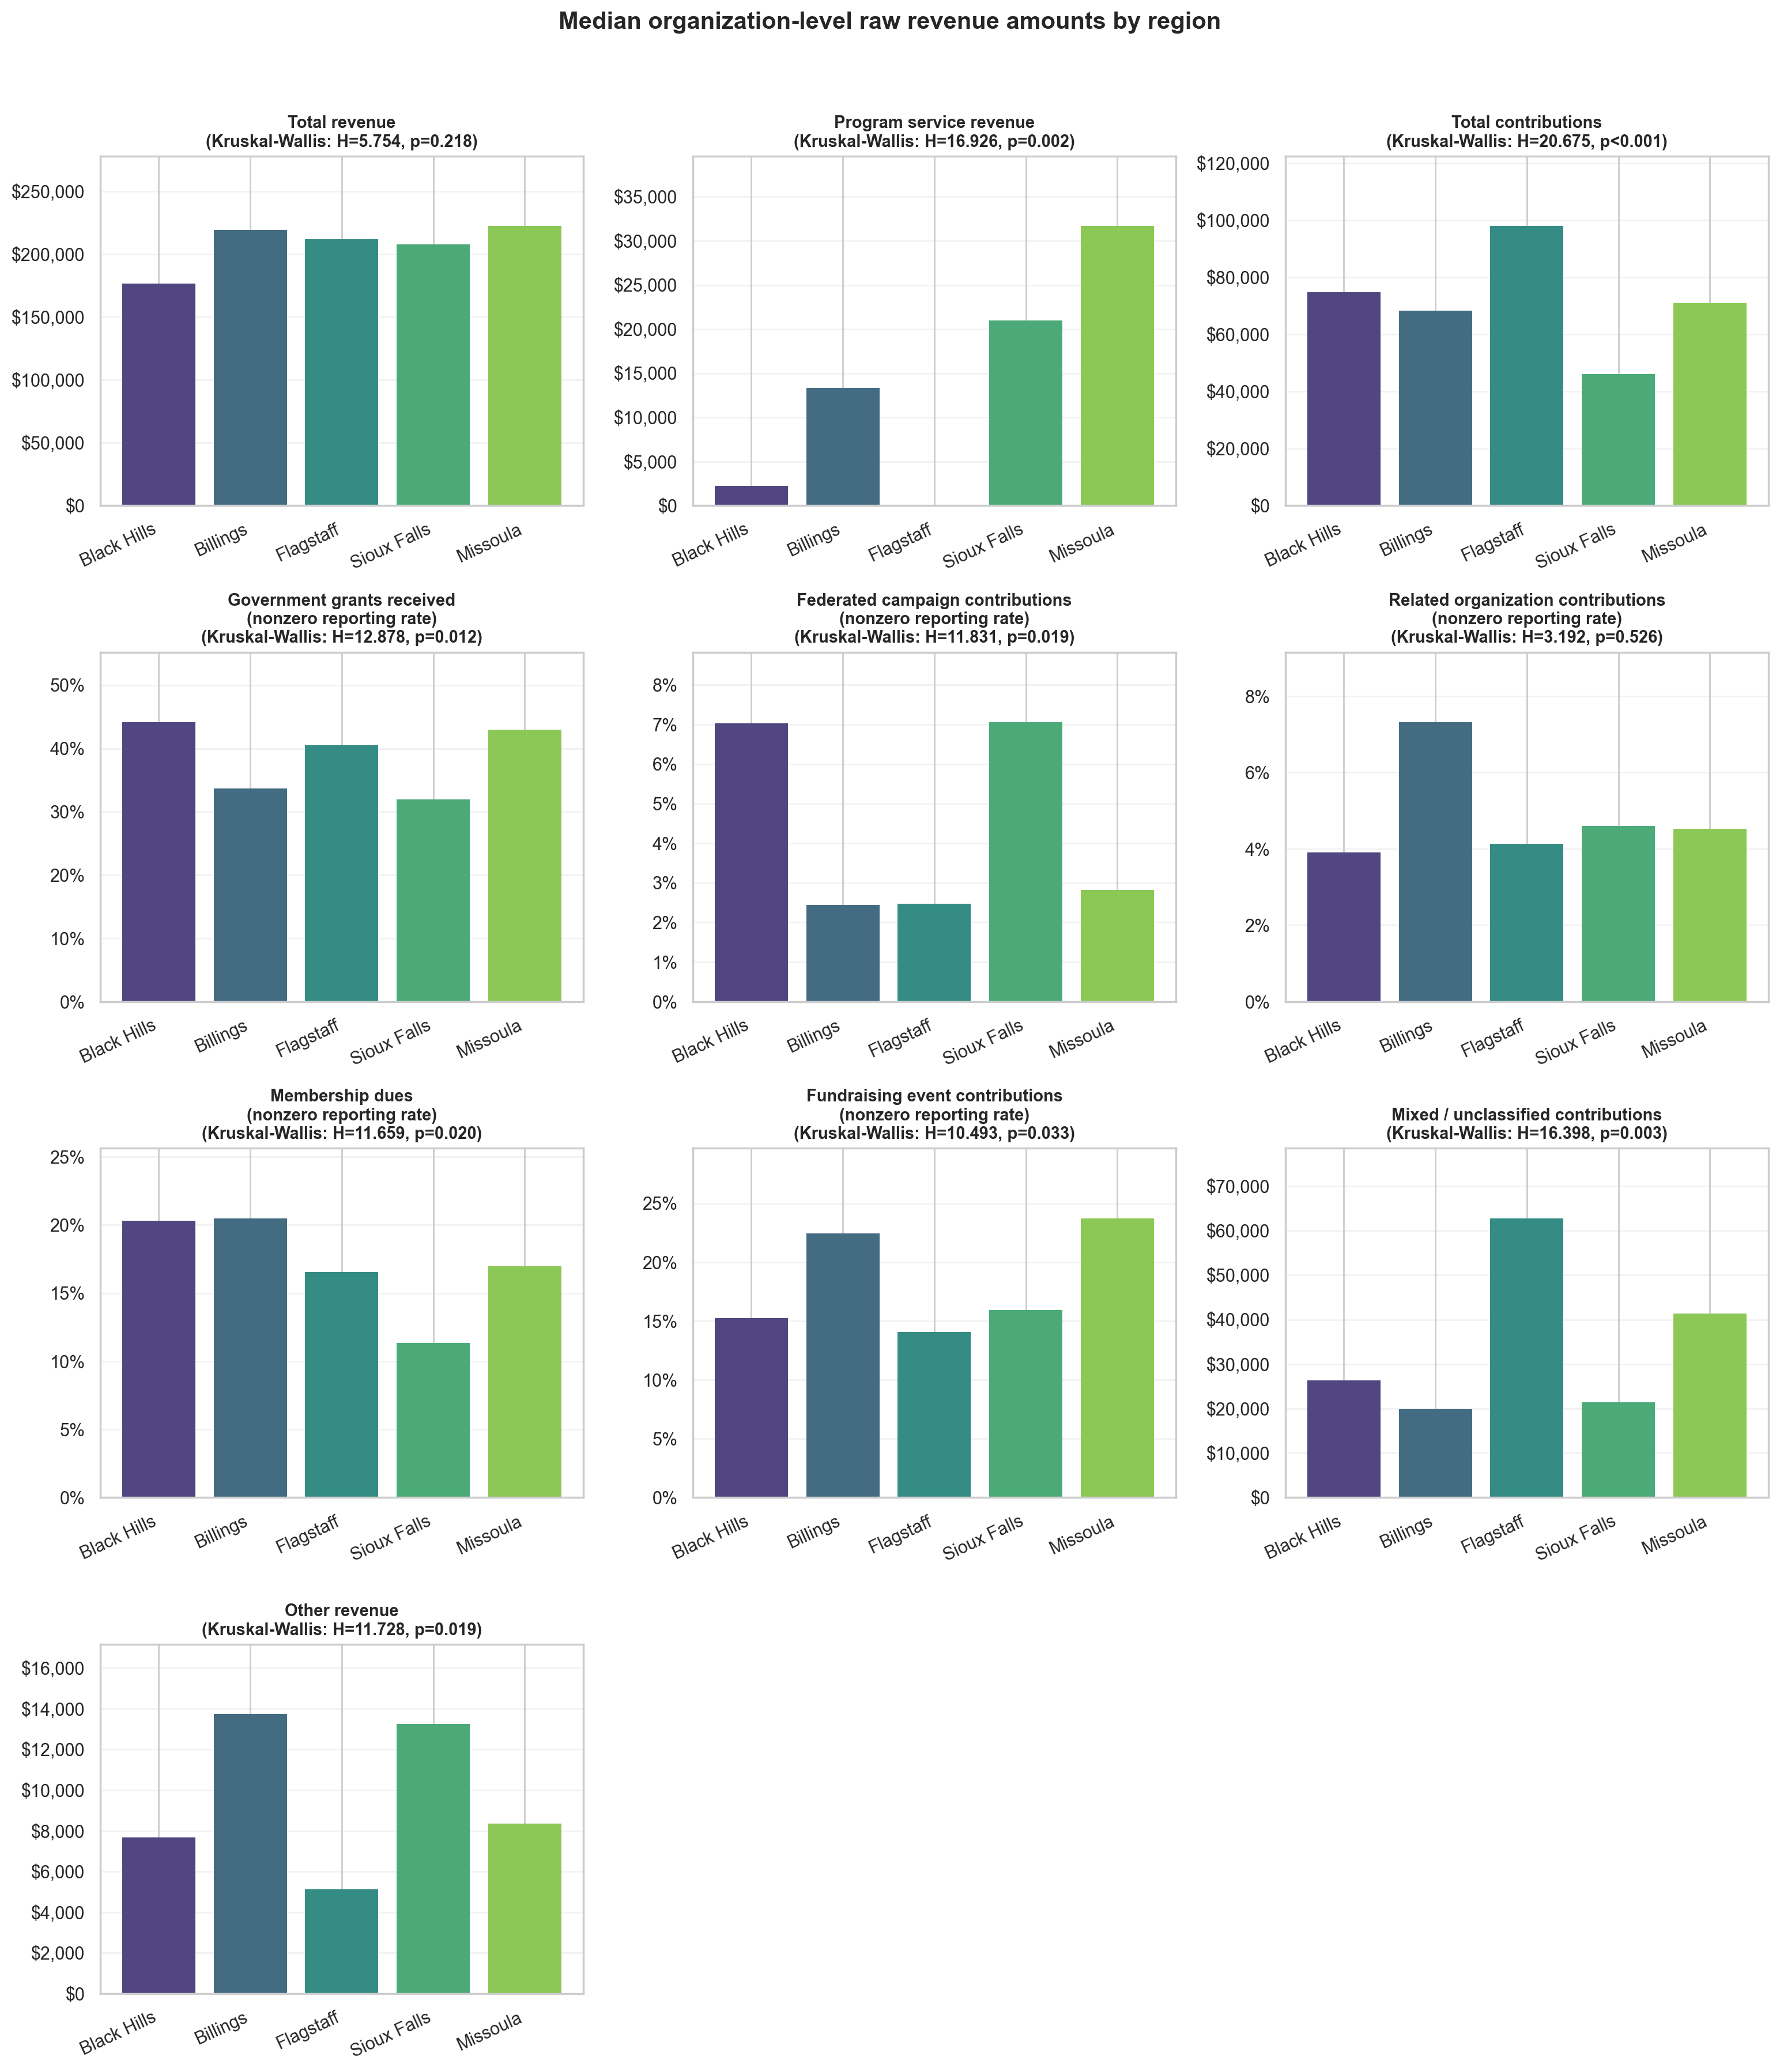

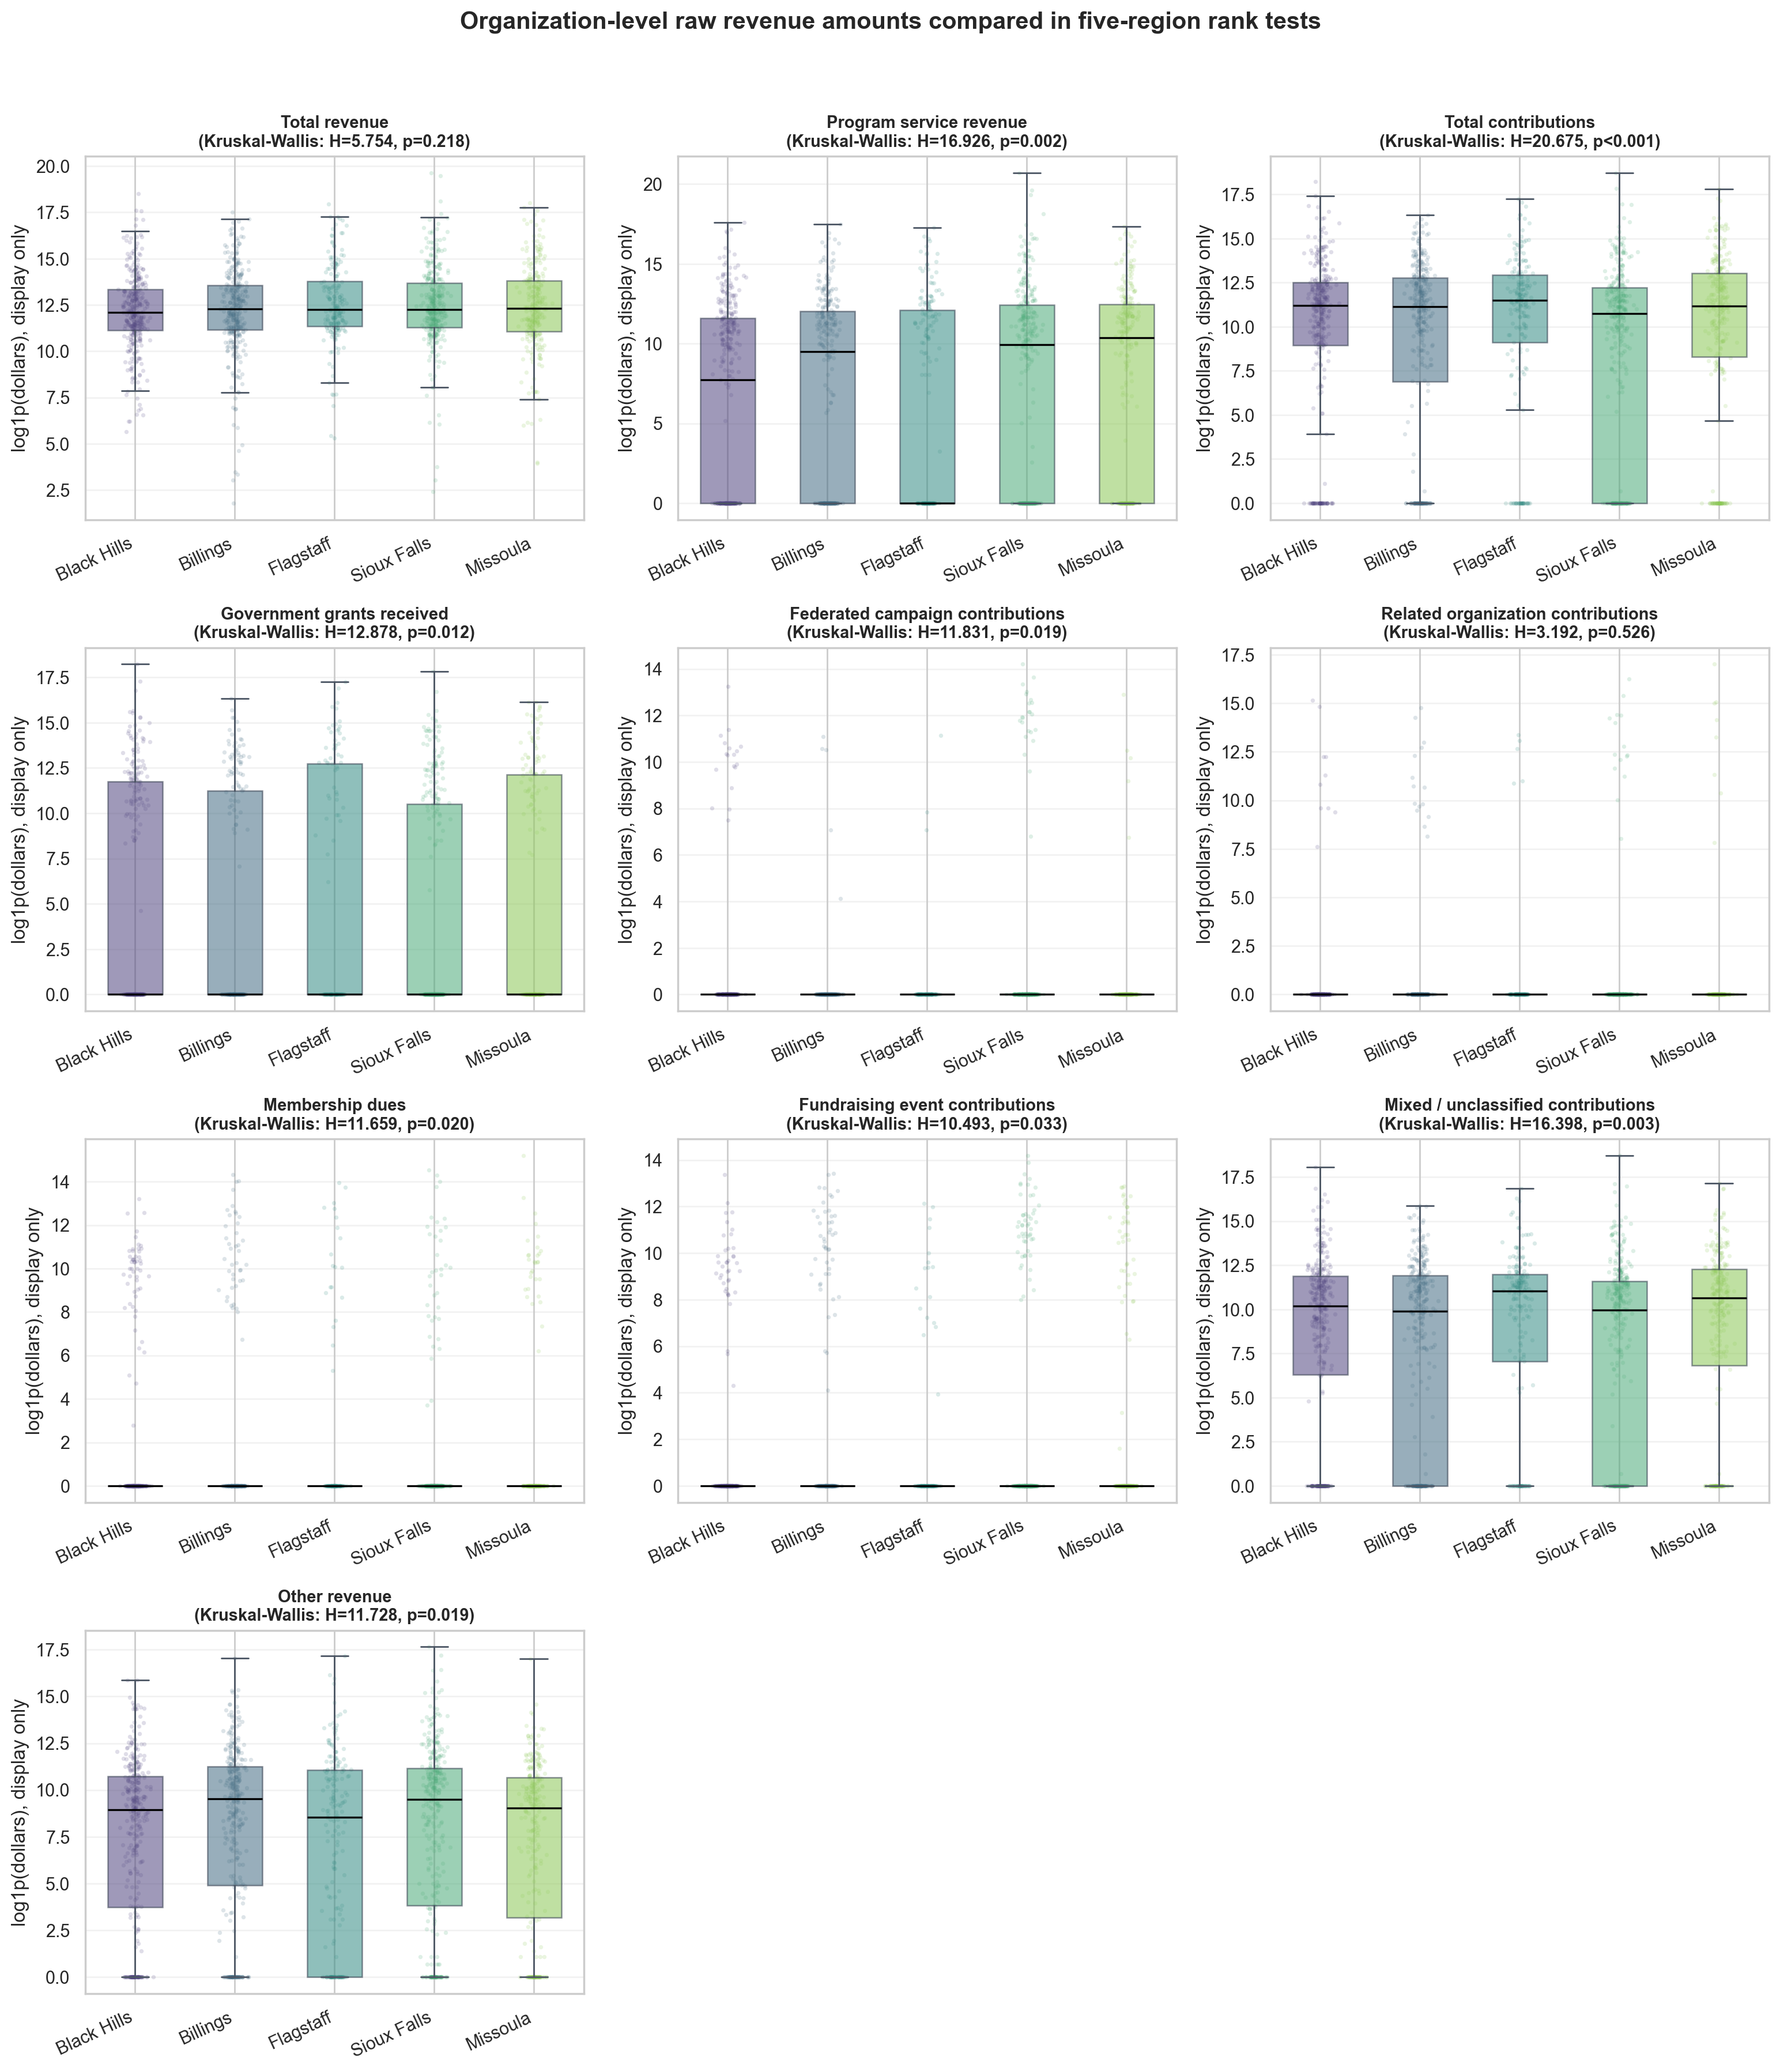

In [6]:
display(Image(filename=str(ASSETS_DIR / 'client_raw_level_median_bars_by_region.png')))
display(Image(filename=str(ASSETS_DIR / 'client_raw_level_distribution_by_region.png')))


## 7. Primary five-region raw-dollar Kruskal-Wallis tests

Kruskal-Wallis compares the rank distributions of organization-level raw dollar amounts across the five regions. It tests whether at least one region differs somewhere in the five-region set.


In [7]:
five_region_raw = r.client_rank_test_table(analysis, r.CLIENT_RAW_LEVEL_VARIABLES, 'region_label')
five_region_raw_display = five_region_raw.copy()
five_region_raw_display['p_value'] = five_region_raw_display['p_value'].map(lambda x: '<0.001' if x < 0.001 else f'{x:.4f}')
five_region_raw_display['fdr_p_value'] = five_region_raw_display['fdr_p_value'].map(lambda x: '<0.001' if x < 0.001 else f'{x:.4f}')
five_region_raw_display['statistic'] = five_region_raw_display['statistic'].map(lambda x: f'{x:.3f}')
five_region_raw_display


,test,variable,statistic,p_value,n,significant_before_fdr,fdr_p_value,significant_after_fdr
0,kruskal_wallis,total_revenue,5.754,0.2183,1799,No,0.2426,No
1,kruskal_wallis,program_service_revenue,16.926,0.0020,1648,Yes,0.0084,Yes
2,kruskal_wallis,total_contributions,20.675,<0.001,1799,Yes,0.0037,Yes
3,kruskal_wallis,government_grants_received,12.878,0.0119,1085,Yes,0.0287,Yes
4,kruskal_wallis,federated_campaigns,11.831,0.0187,1085,Yes,0.0287,Yes
5,kruskal_wallis,related_org_contributions,3.192,0.5263,1085,No,0.5263,No
6,kruskal_wallis,membership_dues,11.659,0.0201,1085,Yes,0.0287,Yes
7,kruskal_wallis,fundraising_events_contributions,10.493,0.0329,1085,Yes,0.0411,Yes
8,kruskal_wallis,mixed_unclassified_contributions,16.398,0.0025,1799,Yes,0.0084,Yes
9,kruskal_wallis,residual_other_revenue,11.728,0.0195,1799,Yes,0.0287,Yes


### Interpretation

The five-region raw-dollar Kruskal-Wallis tests are significant for:

- `program_service_revenue`
- `total_contributions`
- `government_grants_received`
- `federated_campaigns`
- `membership_dues`
- `fundraising_events_contributions`
- `mixed_unclassified_contributions`
- `residual_other_revenue`

They are not significant for:

- `total_revenue`
- `related_org_contributions`

The detailed contribution-source tests now use only rows where that source field is actually available. For the Form 990-only subcomponents, 990-EZ and 990-PF rows are excluded rather than treated as zeros. Several subcomponents still have zero medians because most eligible Form 990 organizations truly report zero on those lines.



## 8. Direct Black Hills vs pooled benchmark raw-dollar follow-up

This is the most direct client comparison: Black Hills versus Billings, Flagstaff, Sioux Falls, and Missoula pooled together.

Mann-Whitney U compares rank distributions. The permutation mean-difference test compares average dollar differences by repeatedly shuffling group labels.


In [8]:
bh_vs_benchmark_raw = r.client_rank_test_table(
    analysis,
    r.CLIENT_RAW_LEVEL_VARIABLES,
    'comparison_group',
    include_permutation=True,
)
bh_vs_benchmark_display = bh_vs_benchmark_raw.copy()
bh_vs_benchmark_display['p_value'] = bh_vs_benchmark_display['p_value'].map(lambda x: '<0.001' if x < 0.001 else f'{x:.4f}')
bh_vs_benchmark_display['fdr_p_value'] = bh_vs_benchmark_display['fdr_p_value'].map(lambda x: '<0.001' if x < 0.001 else f'{x:.4f}')
bh_vs_benchmark_display['statistic'] = bh_vs_benchmark_display['statistic'].map(lambda x: f'{x:.4g}')
bh_vs_benchmark_display


,test,variable,statistic,p_value,n,significant_before_fdr,fdr_p_value,significant_after_fdr,direction
0,mann_whitney,total_revenue,2.71e+05,0.0365,1799,Yes,0.2365,No,Black Hills lower
1,permutation_mean_diff,total_revenue,-1.36e+06,0.4053,1799,No,0.5066,No,Black Hills lower
2,mann_whitney,program_service_revenue,2.241e+05,0.0022,1648,Yes,0.0447,Yes,Black Hills lower
3,permutation_mean_diff,program_service_revenue,-1.521e+06,0.2649,1648,No,0.4080,No,Black Hills lower
4,mann_whitney,total_contributions,3.009e+05,0.2652,1799,No,0.4080,No,Black Hills higher
5,permutation_mean_diff,total_contributions,1.697e+05,0.6072,1799,No,0.6392,No,Black Hills higher
6,mann_whitney,government_grants_received,1.132e+05,0.0648,1085,No,0.2365,No,Black Hills higher
7,permutation_mean_diff,government_grants_received,2.995e+05,0.2344,1085,No,0.4080,No,Black Hills higher
8,mann_whitney,federated_campaigns,1.088e+05,0.0984,1085,No,0.2365,No,Black Hills higher
9,permutation_mean_diff,federated_campaigns,-4170,0.3938,1085,No,0.5066,No,Black Hills lower


### Interpretation

The clearest Black Hills-specific raw-dollar result is **government grants** under Mann-Whitney U. Because government grants are zero-heavy, this should be read as a rank/nonzero-rate difference rather than a simple median-dollar difference; the median government-grant amount is $0 in every region.

Membership dues also differ by Mann-Whitney U, but the mean-difference direction is lower for Black Hills because the dollar amounts are highly skewed. Fundraising event contributions are lower for Black Hills under the permutation mean-difference test.

The government-grants permutation mean-difference test is not significant, so the analysis should not claim that Black Hills has a statistically higher average government-grant dollar amount.


## 9. Exploratory pairwise raw-dollar tests

The pooled benchmark table combines all benchmark regions. These pairwise tests compare Black Hills to each benchmark region separately. They are exploratory follow-ups to the five-region test.


In [9]:
pairwise_raw = r.client_pairwise_black_hills_region_tests(analysis, r.CLIENT_RAW_LEVEL_VARIABLES)
pairwise_sig = pairwise_raw.loc[pairwise_raw['significant_before_fdr'].eq('Yes')].copy()
pairwise_sig['p_value'] = pairwise_sig['p_value'].map(lambda x: '<0.001' if x < 0.001 else f'{x:.4f}')
pairwise_sig['fdr_p_value'] = pairwise_sig['fdr_p_value'].map(lambda x: '<0.001' if x < 0.001 else f'{x:.4f}')
pairwise_sig[['comparison', 'test', 'variable', 'direction', 'p_value', 'fdr_p_value', 'significant_after_fdr']]


,comparison,test,variable,direction,p_value,fdr_p_value,significant_after_fdr
4,Black Hills vs Billings,mann_whitney,federated_campaigns,Black Hills higher,0.0240,0.1200,No
7,Black Hills vs Billings,mann_whitney,fundraising_events_contributions,Black Hills lower,0.0235,0.1200,No
9,Black Hills vs Billings,mann_whitney,residual_other_revenue,Black Hills lower,0.0300,0.1201,No
16,Black Hills vs Billings,permutation_mean_diff,membership_dues,Black Hills lower,0.0060,0.0850,No
17,Black Hills vs Billings,permutation_mean_diff,fundraising_events_contributions,Black Hills lower,0.0085,0.0850,No
20,Black Hills vs Flagstaff,mann_whitney,total_revenue,Black Hills lower,0.0373,0.2565,No
36,Black Hills vs Flagstaff,permutation_mean_diff,membership_dues,Black Hills lower,0.0210,0.2565,No
39,Black Hills vs Flagstaff,permutation_mean_diff,residual_other_revenue,Black Hills lower,0.0385,0.2565,No
41,Black Hills vs Sioux Falls,mann_whitney,program_service_revenue,Black Hills lower,0.0027,0.0204,Yes
42,Black Hills vs Sioux Falls,mann_whitney,total_contributions,Black Hills higher,0.0021,0.0204,Yes


### Interpretation

Black Hills differs most broadly from Sioux Falls. Government grants differ most clearly against Billings and Sioux Falls. The detailed subcategories add more context: some pairwise differences appear in federated campaigns, membership dues, and fundraising event contributions, but these are zero-heavy and should be treated as supporting detail rather than the main Q9 headline.


## 10. Year-by-year raw-dollar checks

The year-by-year checks are retained for reproducibility, but the current client-facing run is restricted to tax year 2022.


In [10]:
year_five_raw = r.client_year_by_year_rank_tables(analysis, r.CLIENT_RAW_LEVEL_VARIABLES, 'region_label')
year_direct_raw = r.client_year_by_year_rank_tables(
    analysis,
    r.CLIENT_RAW_LEVEL_VARIABLES,
    'comparison_group',
    include_permutation=True,
)

year_five_display = year_five_raw.copy()
for col in ['p_value', 'fdr_p_value']:
    year_five_display[col] = year_five_display[col].map(lambda x: '<0.001' if x < 0.001 else f'{x:.4f}')
year_five_display['statistic'] = year_five_display['statistic'].map(lambda x: f'{x:.3f}')
year_five_display


,tax_year,test,variable,statistic,p_value,n,significant_before_fdr,fdr_p_value,significant_after_fdr
0,2022,kruskal_wallis,total_revenue,5.754,0.2183,1799,No,0.2426,No
1,2022,kruskal_wallis,program_service_revenue,16.926,0.0020,1648,Yes,0.0084,Yes
2,2022,kruskal_wallis,total_contributions,20.675,<0.001,1799,Yes,0.0037,Yes
3,2022,kruskal_wallis,government_grants_received,12.878,0.0119,1085,Yes,0.0287,Yes
4,2022,kruskal_wallis,federated_campaigns,11.831,0.0187,1085,Yes,0.0287,Yes
5,2022,kruskal_wallis,related_org_contributions,3.192,0.5263,1085,No,0.5263,No
6,2022,kruskal_wallis,membership_dues,11.659,0.0201,1085,Yes,0.0287,Yes
7,2022,kruskal_wallis,fundraising_events_contributions,10.493,0.0329,1085,Yes,0.0411,Yes
8,2022,kruskal_wallis,mixed_unclassified_contributions,16.398,0.0025,1799,Yes,0.0084,Yes
9,2022,kruskal_wallis,residual_other_revenue,11.728,0.0195,1799,Yes,0.0287,Yes


In [11]:
year_direct_display = year_direct_raw.copy()
for col in ['p_value', 'fdr_p_value']:
    year_direct_display[col] = year_direct_display[col].map(lambda x: '<0.001' if x < 0.001 else f'{x:.4f}')
year_direct_display['statistic'] = year_direct_display['statistic'].map(lambda x: f'{x:.4g}')
year_direct_display


,tax_year,test,variable,statistic,p_value,n,significant_before_fdr,fdr_p_value,significant_after_fdr,direction
0,2022,mann_whitney,total_revenue,2.71e+05,0.0365,1799,Yes,0.2365,No,Black Hills lower
1,2022,permutation_mean_diff,total_revenue,-1.36e+06,0.4053,1799,No,0.5066,No,Black Hills lower
2,2022,mann_whitney,program_service_revenue,2.241e+05,0.0022,1648,Yes,0.0447,Yes,Black Hills lower
3,2022,permutation_mean_diff,program_service_revenue,-1.521e+06,0.2649,1648,No,0.4080,No,Black Hills lower
4,2022,mann_whitney,total_contributions,3.009e+05,0.2652,1799,No,0.4080,No,Black Hills higher
5,2022,permutation_mean_diff,total_contributions,1.697e+05,0.6072,1799,No,0.6392,No,Black Hills higher
6,2022,mann_whitney,government_grants_received,1.132e+05,0.0648,1085,No,0.2365,No,Black Hills higher
7,2022,permutation_mean_diff,government_grants_received,2.995e+05,0.2344,1085,No,0.4080,No,Black Hills higher
8,2022,mann_whitney,federated_campaigns,1.088e+05,0.0984,1085,No,0.2365,No,Black Hills higher
9,2022,permutation_mean_diff,federated_campaigns,-4170,0.3938,1085,No,0.5066,No,Black Hills lower


## 11. Descriptive stacked revenue-mix charts

The stacked bars below show normalized aggregate-dollar revenue-source mix using the detailed source categories. They sum dollars within each group or region, then convert those totals to percentages.

These charts are useful for presentation, but they are **descriptive only**. They are not the data used in the primary Kruskal-Wallis or Mann-Whitney tests.


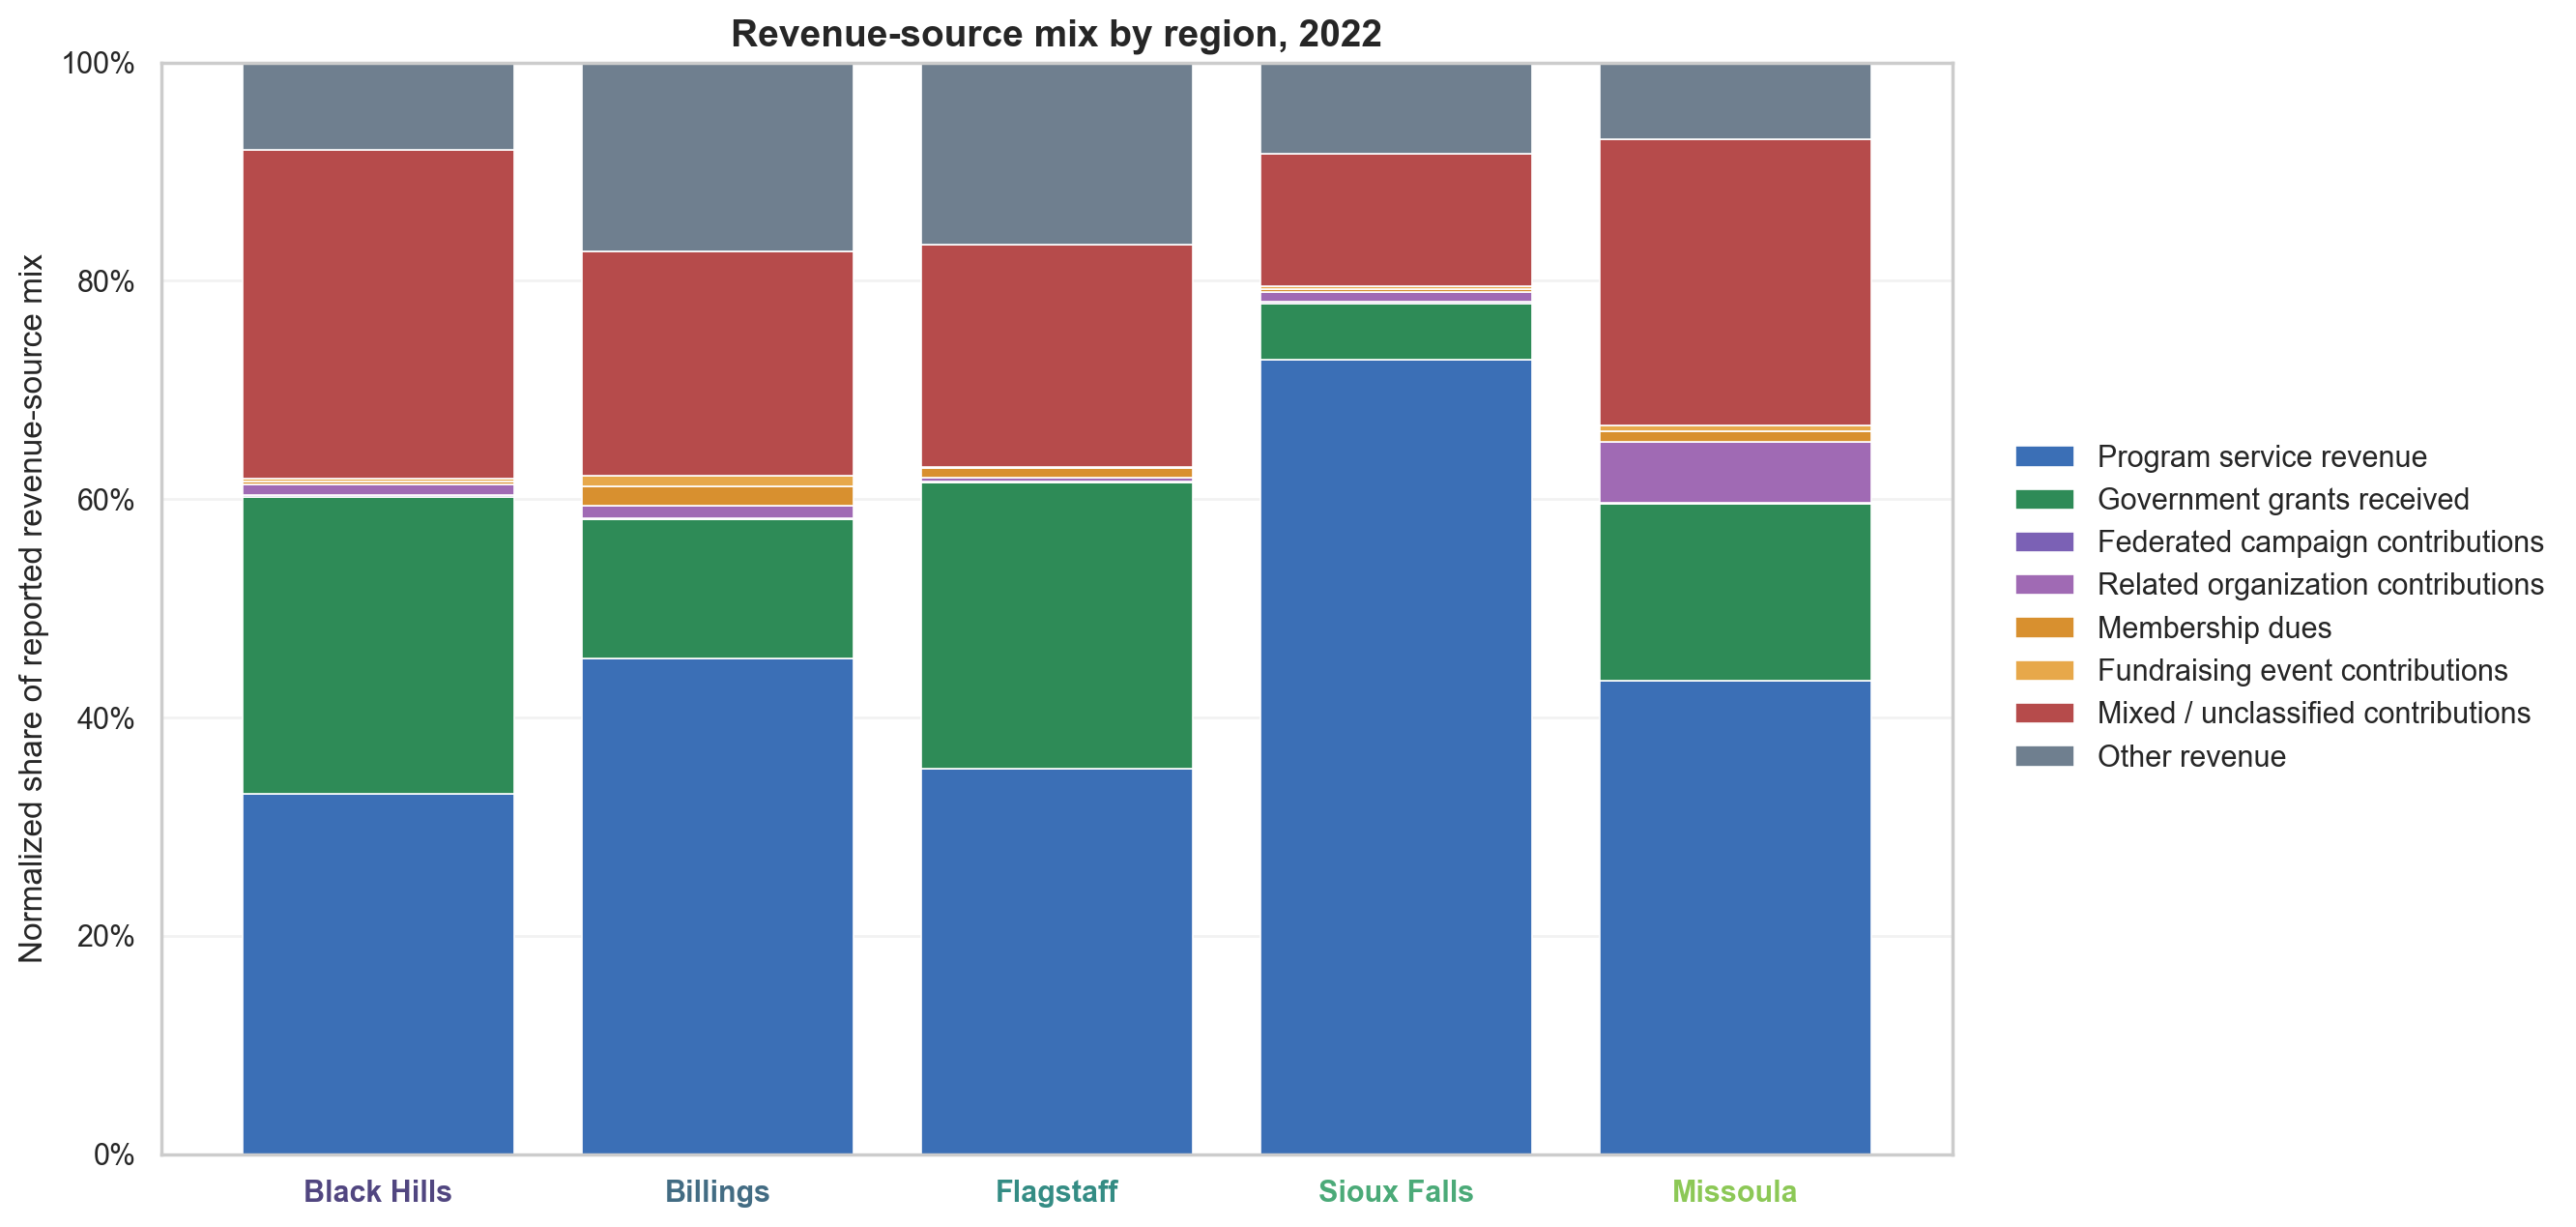

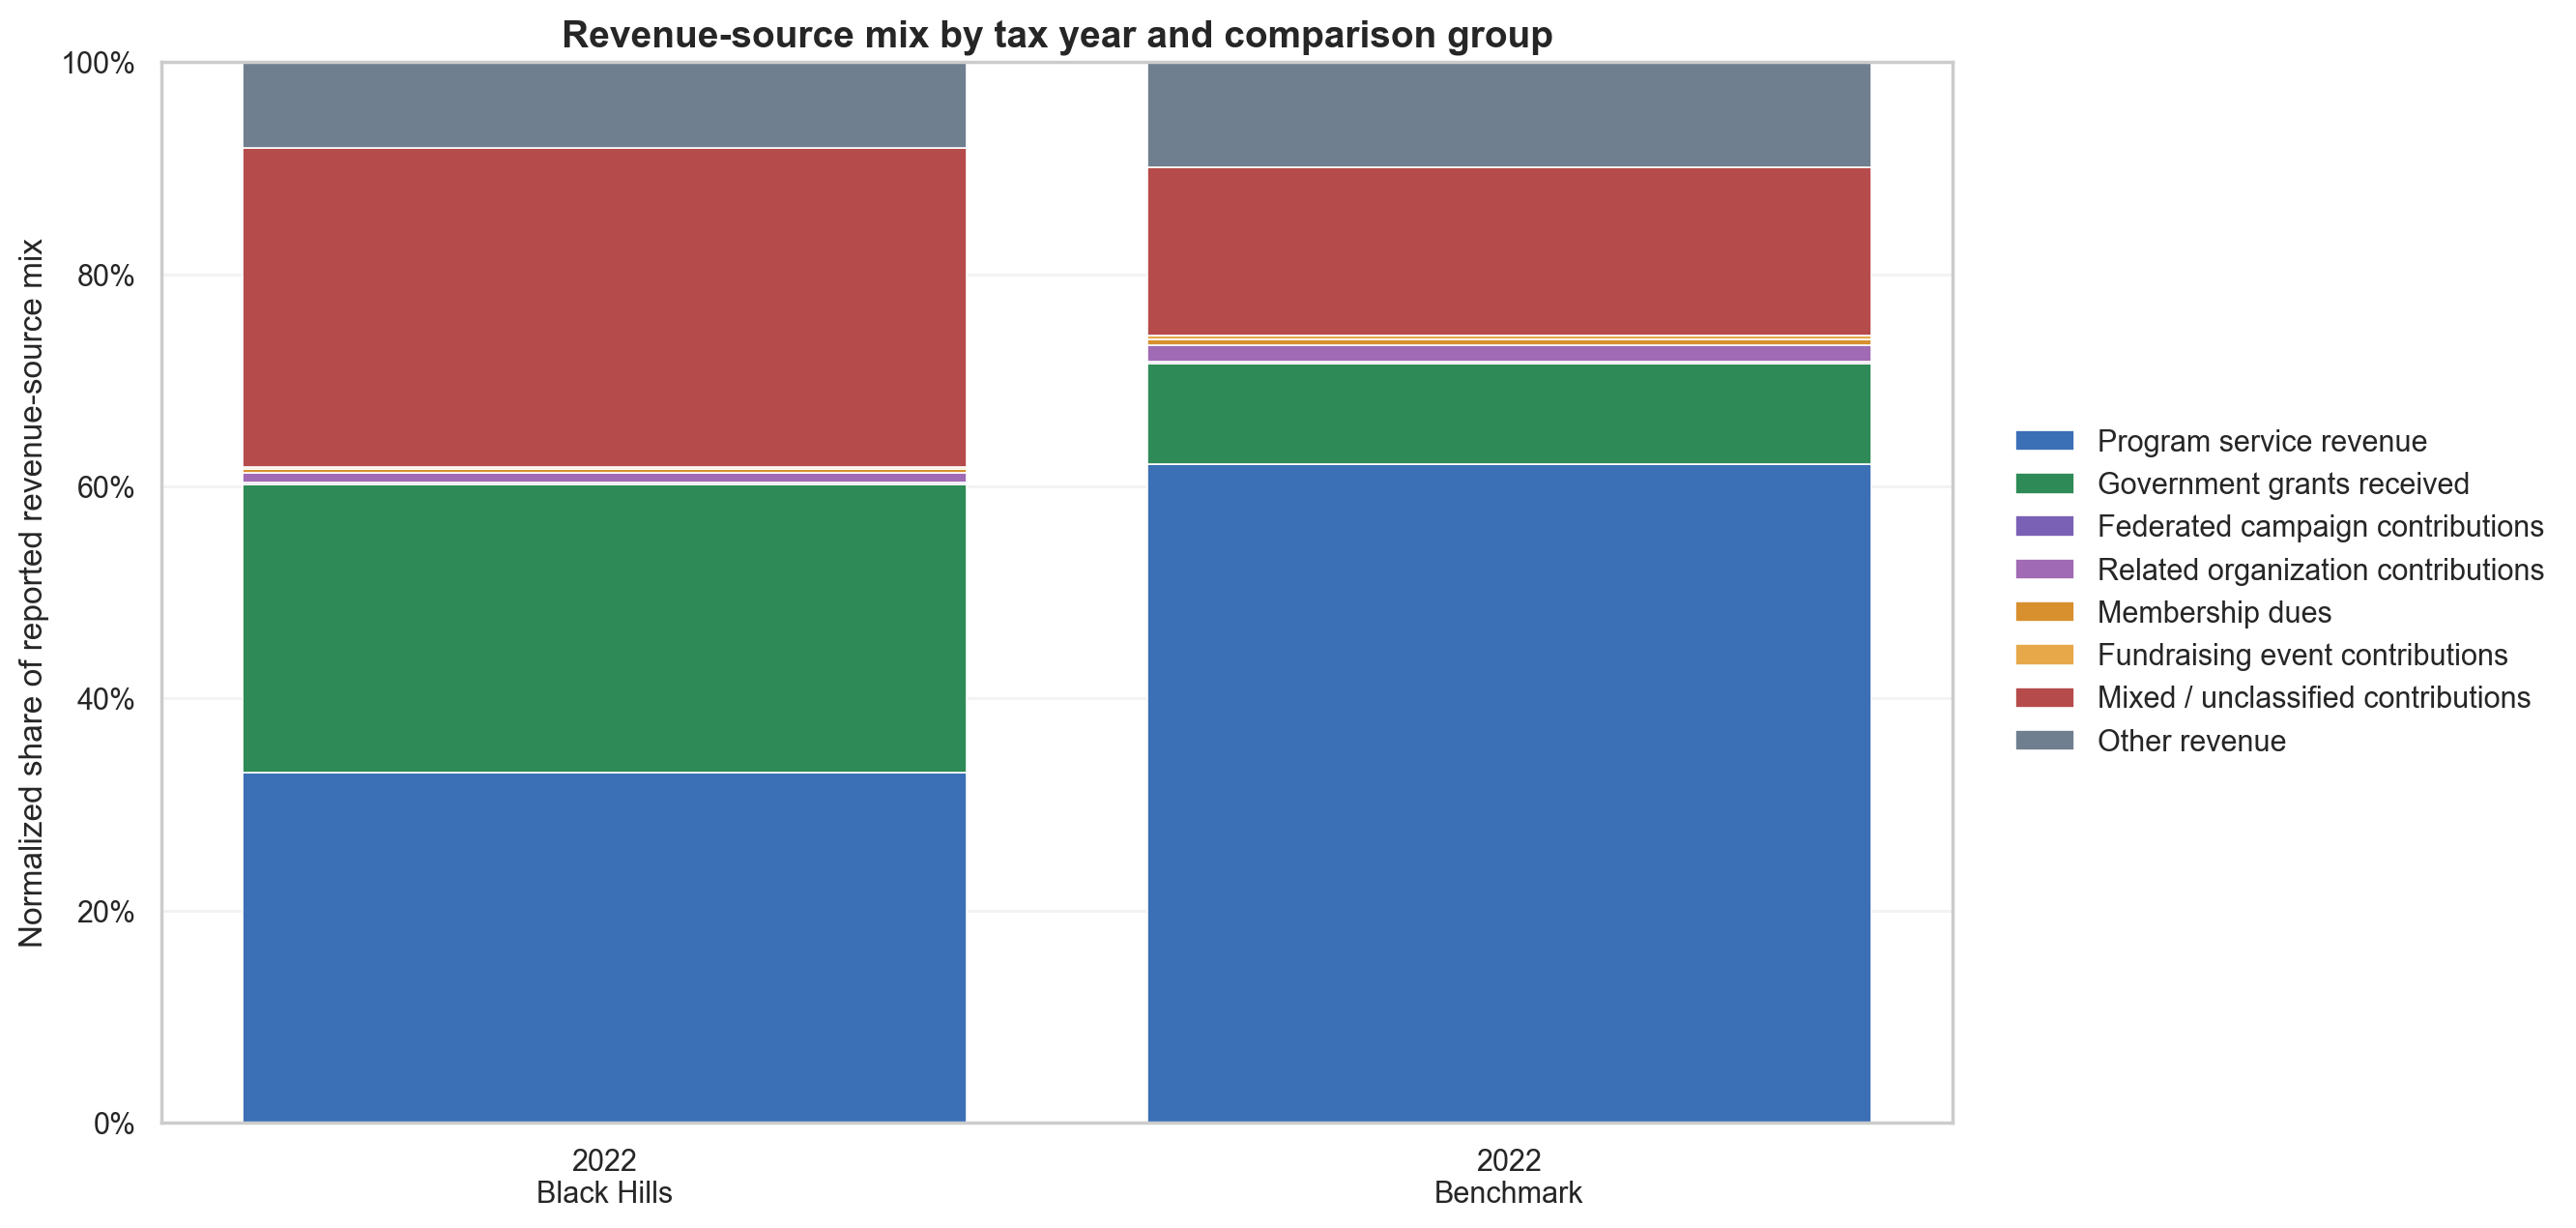

In [12]:
display(Image(filename=str(ASSETS_DIR / 'client_stacked_revenue_mix_by_five_regions.png')))
display(Image(filename=str(ASSETS_DIR / 'client_stacked_revenue_mix_by_year.png')))


## 12. Supplemental revenue-mix / compositional context

Share-based tests remain available as supplemental context when the question is specifically about revenue mix. They should not be the headline Q9 test because source shares are compositional.

The detailed categories make the mix charts more informative, but they do not create a clean foundation-grants or confirmed individual-donations category. Form 990 Line 1f and all 990-EZ/PF contribution totals remain mixed / unclassified.


In [13]:
share_five = r.client_rank_test_table(analysis, r.SHARE_COMPONENTS, 'region_label')
share_direct = r.client_rank_test_table(analysis, r.SHARE_COMPONENTS, 'comparison_group', include_permutation=True)

share_five_display = share_five.copy()
for col in ['p_value', 'fdr_p_value']:
    share_five_display[col] = share_five_display[col].map(lambda x: '<0.001' if x < 0.001 else f'{x:.4f}')
share_five_display['statistic'] = share_five_display['statistic'].map(lambda x: f'{x:.3f}')
share_five_display


,test,variable,statistic,p_value,n,significant_before_fdr,fdr_p_value,significant_after_fdr
0,kruskal_wallis,program_service_revenue_share,18.860,<0.001,1648,Yes,0.0022,Yes
1,kruskal_wallis,government_grants_received_share,17.088,0.0019,1085,Yes,0.0037,Yes
2,kruskal_wallis,federated_campaigns_share,11.401,0.0224,1085,Yes,0.0256,Yes
3,kruskal_wallis,related_org_contributions_share,3.369,0.4980,1085,No,0.4980,No
4,kruskal_wallis,membership_dues_share,11.601,0.0206,1085,Yes,0.0256,Yes
5,kruskal_wallis,fundraising_events_contributions_share,11.691,0.0198,1085,Yes,0.0256,Yes
6,kruskal_wallis,mixed_unclassified_contributions_share,21.597,<0.001,1799,Yes,0.0019,Yes
7,kruskal_wallis,residual_other_revenue_share,19.620,<0.001,1799,Yes,0.0022,Yes


In [14]:
share_direct_display = share_direct.copy()
for col in ['p_value', 'fdr_p_value']:
    share_direct_display[col] = share_direct_display[col].map(lambda x: '<0.001' if x < 0.001 else f'{x:.4f}')
share_direct_display['statistic'] = share_direct_display['statistic'].map(lambda x: f'{x:.4g}')
share_direct_display


,test,variable,statistic,p_value,n,significant_before_fdr,fdr_p_value,significant_after_fdr,direction
0,mann_whitney,program_service_revenue_share,2.265e+05,0.0059,1648,Yes,0.0302,Yes,Black Hills lower
1,permutation_mean_diff,program_service_revenue_share,-0.06152,0.0130,1648,Yes,0.0416,Yes,Black Hills lower
2,mann_whitney,government_grants_received_share,1.172e+05,0.0036,1085,Yes,0.0289,Yes,Black Hills higher
3,permutation_mean_diff,government_grants_received_share,0.05875,0.0025,1085,Yes,0.0289,Yes,Black Hills higher
4,mann_whitney,federated_campaigns_share,1.089e+05,0.0924,1085,No,0.1642,No,Black Hills higher
5,permutation_mean_diff,federated_campaigns_share,0.002299,0.6642,1085,No,0.6642,No,Black Hills higher
6,mann_whitney,related_org_contributions_share,1.047e+05,0.3875,1085,No,0.4769,No,Black Hills lower
7,permutation_mean_diff,related_org_contributions_share,-0.003679,0.5377,1085,No,0.5736,No,Black Hills lower
8,mann_whitney,membership_dues_share,1.109e+05,0.0919,1085,No,0.1642,No,Black Hills lower
9,permutation_mean_diff,membership_dues_share,-0.01347,0.4648,1085,No,0.5312,No,Black Hills lower


## 13. Final answer

**Yes. There are statistically significant differences in revenue-source dollar distributions across Black Hills and the benchmark regions.**

The primary raw-dollar five-region Kruskal-Wallis tests show significant differences for total contributions, government grants, federated campaign contributions, membership dues, fundraising event contributions, mixed / unclassified contributions, and other revenue. They do not show significant differences for total revenue, program service revenue, or related organization contributions.

For the direct Black Hills vs pooled benchmark comparison, the clearest Black Hills-specific result remains government grants under Mann-Whitney U. Because government grants are zero-heavy, this should be described as a rank/nonzero-rate difference, not as a higher median grant amount. The permutation mean-difference check for government grants is not significant, so we should not overclaim a higher average grant-dollar amount.

The more detailed contribution categories add useful context. Membership dues and fundraising event contributions show additional Black Hills-vs-benchmark signals, but they should be interpreted carefully because the categories are zero-heavy and are individual-adjacent proxies rather than confirmed individual giving.

The stacked revenue-mix charts and share-based tests remain useful supplemental context, but the primary Q9 answer should be based on raw-dollar non-parametric comparisons.
